# 🔍 Fraud Detection Model Analysis — IEEE-CIS Dataset

**Project:** FinRiskGuard — Financial Risk Intelligence Platform  
**Dataset:** IEEE-CIS Fraud Detection (Vesta Corporation, Kaggle)  
**Validation set:** 118,108 transactions | Fraud rate: 3.44% | Class imbalance: 27.6:1

---

## Pipeline Architecture

| Stage | Module | Details |
|---|---|---|
| Load | `loader.py` | Merge transaction + identity tables |
| Split | `splitter.py` | Temporal split — last 20% by time (no random shuffle) |
| Feature Engineering | `feature_engineer.py` | 47 features: D-normalization, UID, email/browser risk, frequency encoding |
| Preprocessing | `preprocessor.py` | OrdinalEncoder, NaN flags, card1 group imputation |
| Feature Selection | `feature_selector.py` | MI + XGB rank-based, top 200 + force-include D_normalized |
| Training | `fraud_detector.py` | XGB + LGB + CatBoost, Optuna 100 trials, calibrated stacking |

**Primary metric:** AUC-ROC (competition standard)  
**Secondary metric:** AUC-PR (critical for 27.6:1 class imbalance)

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
)

ROOT_DIR = Path(r"C:\Users\sharg\Desktop\github\FinRiskGuard")
MODELS_DIR   = ROOT_DIR / "outputs" / "models" / "fraud"
FEATURES_DIR = ROOT_DIR / "data"    / "features" / "fraud"
FIG_BASE     = ROOT_DIR / "outputs" / "figures"  / "fraud"

for sub in ["comparison", "model", "shap"]:
    (FIG_BASE / sub).mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"]    = (12, 6)
plt.rcParams["font.size"]         = 12
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

val   = pd.read_parquet(FEATURES_DIR / "val_fraud_features.parquet")
X_val = val.drop(columns=["isFraud"])
y_val = val["isFraud"]

with open(MODELS_DIR / "fraud_model_metadata.json") as f:
    metadata = json.load(f)

leaderboard = metadata["leaderboard"]
model_name  = metadata["model_name"]
threshold   = metadata["threshold"]

print("=" * 50)
print(f"Best model  : {model_name}")
print(f"AUC-ROC     : {metadata['auc_roc']:.4f}")
print(f"AUC-PR      : {metadata['auc_pr']:.4f}")
print(f"F1          : {metadata['f1']:.4f}")
print(f"Precision   : {metadata['precision']:.4f}")
print(f"Recall      : {metadata['recall']:.4f}")
print(f"Threshold   : {threshold:.3f}")
print(f"Val shape   : {X_val.shape}")
print(f"Fraud count : {y_val.sum():,} ({y_val.mean()*100:.2f}%)")

Best model  : tuned_xgb
AUC-ROC     : 0.9258
AUC-PR      : 0.5637
F1          : 0.4389
Precision   : 0.3187
Recall      : 0.7050
Threshold   : 0.440
Val shape   : (118108, 204)
Fraud count : 4,064 (3.44%)


---
## 1. Model Comparison Leaderboard

All 7 trained models compared across three metrics:

- **AUC-ROC** — primary metric: discrimination ability across all thresholds
- **AUC-PR** — secondary metric: precision-recall tradeoff (critical for 27.6:1 imbalance)
- **F1-score** — harmonic mean of precision and recall at default threshold

Training strategy per model:
- `baseline_*` — default hyperparameters, early stopping on validation AUC
- `tuned_*` — Optuna 100-trial Bayesian search, AUC-ROC objective
- `stacking` — calibrated base models (isotonic regression) + LogisticRegression meta-learner, TimeSeriesSplit CV

> **Saved:** `outputs/figures/fraud/comparison/01_model_leaderboard.png`

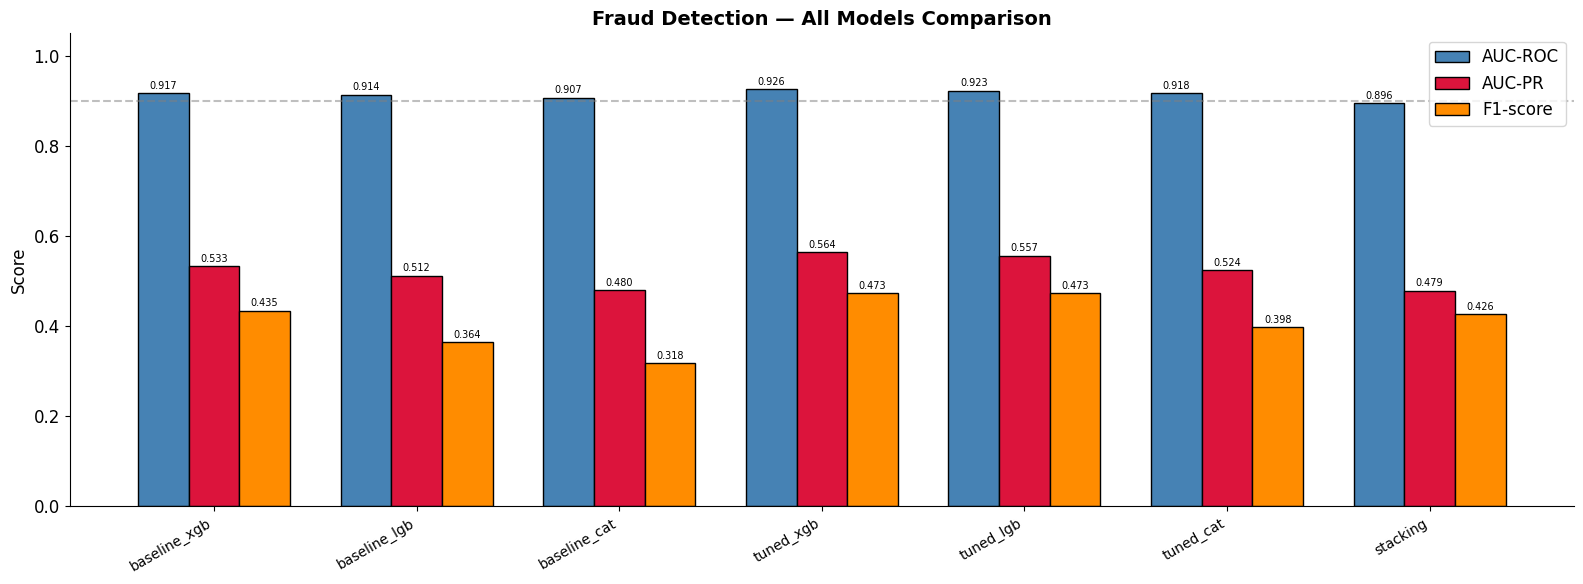

Leaderboard (by AUC-ROC):
  #1 tuned_xgb            AUC-ROC=0.9258 | AUC-PR=0.5637 | F1=0.4728 ← BEST
  #2 tuned_lgb            AUC-ROC=0.9231 | AUC-PR=0.5567 | F1=0.4734
  #3 tuned_cat            AUC-ROC=0.9180 | AUC-PR=0.5244 | F1=0.3983
  #4 baseline_xgb         AUC-ROC=0.9169 | AUC-PR=0.5326 | F1=0.4348
  #5 baseline_lgb         AUC-ROC=0.9140 | AUC-PR=0.5124 | F1=0.3641
  #6 baseline_cat         AUC-ROC=0.9072 | AUC-PR=0.4803 | F1=0.3178
  #7 stacking             AUC-ROC=0.8957 | AUC-PR=0.4791 | F1=0.4264


In [2]:
names = list(leaderboard.keys())
aucs  = [v["auc_roc"] for v in leaderboard.values()]
auprs = [v["auc_pr"]  for v in leaderboard.values()]
f1s   = [v["f1"]      for v in leaderboard.values()]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - width, aucs,  width, label="AUC-ROC",  color="steelblue",  edgecolor="black")
b2 = ax.bar(x,         auprs, width, label="AUC-PR",   color="crimson",    edgecolor="black")
b3 = ax.bar(x + width, f1s,   width, label="F1-score", color="darkorange", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Fraud Detection — All Models Comparison", fontsize=14, fontweight="bold")
ax.legend()
ax.axhline(y=0.90, color="gray", linestyle="--", alpha=0.5, label="0.90 reference")

for bar in [*b1, *b2, *b3]:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(FIG_BASE / "comparison" / "01_model_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("Leaderboard (by AUC-ROC):")
for i, (name, m) in enumerate(
    sorted(leaderboard.items(), key=lambda x: x[1]['auc_roc'], reverse=True), 1
):
    marker = " ← BEST" if name == model_name else ""
    print(f"  #{i} {name:<20} AUC-ROC={m['auc_roc']:.4f} | AUC-PR={m['auc_pr']:.4f} | F1={m['f1']:.4f}{marker}")

---
## 2. ROC and Precision-Recall Curves

**ROC Curve** (left): Measures the model's ability to discriminate fraud from legitimate transactions across all decision thresholds. Higher AUC = better discrimination.

**Precision-Recall Curve** (right): More informative than ROC for highly imbalanced datasets. With 27.6:1 imbalance, a naive classifier gets 96.56% accuracy — PR curve exposes true performance on the minority (fraud) class.

- Solid lines = tuned models
- Dashed lines = baseline models

> **Saved:** `outputs/figures/fraud/model/02_roc_pr_curves.png`

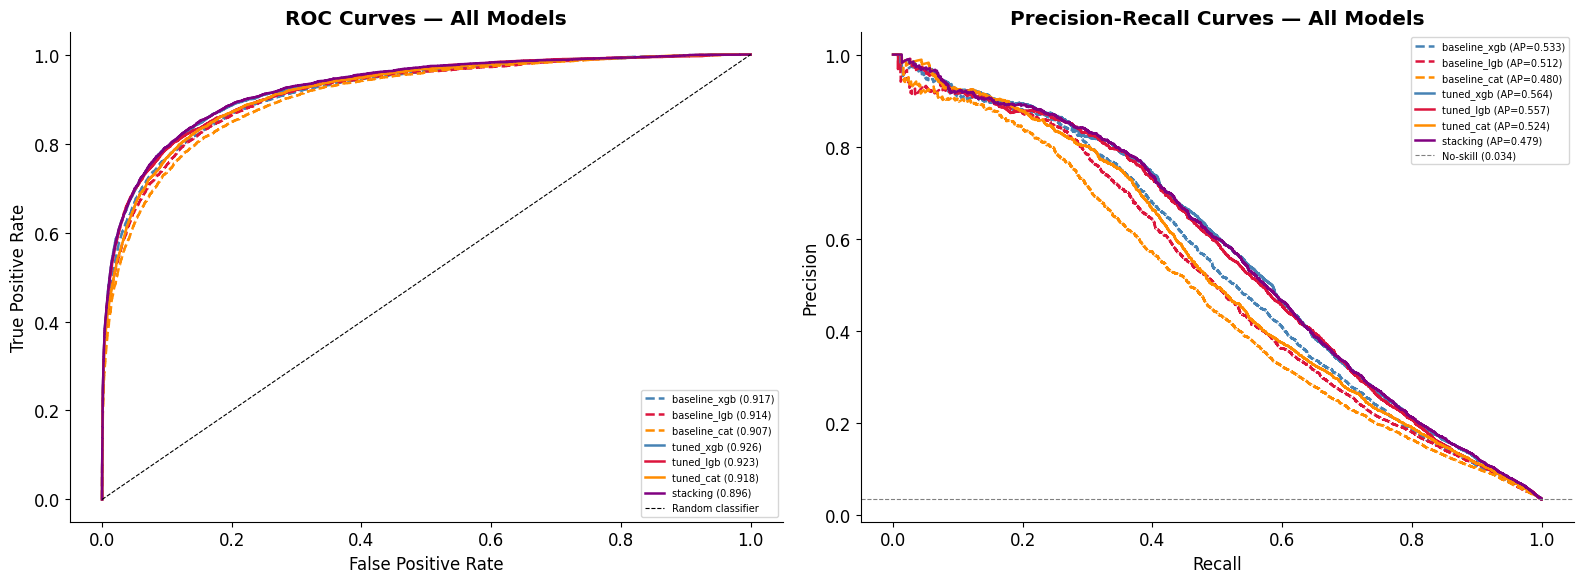

Saved: model/02_roc_pr_curves.png


In [3]:
COLORS = {
    "baseline_xgb": ("steelblue",  "--"),
    "baseline_lgb": ("crimson",    "--"),
    "baseline_cat": ("darkorange", "--"),
    "tuned_xgb":    ("steelblue",  "-"),
    "tuned_lgb":    ("crimson",    "-"),
    "tuned_cat":    ("darkorange", "-"),
    "stacking":     ("purple",     "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, metrics in leaderboard.items():
    color, ls = COLORS.get(name, ("gray", "-"))
    try:
        if name == "stacking":
            xgb_p = joblib.load(MODELS_DIR / "tuned_xgb.pkl").predict_proba(X_val)[:, 1]
            lgb_p = joblib.load(MODELS_DIR / "tuned_lgb.pkl").predict_proba(X_val)[:, 1]
            cat_p = joblib.load(MODELS_DIR / "tuned_cat.pkl").predict_proba(X_val)[:, 1]
            meta  = joblib.load(MODELS_DIR / "stacking_meta.pkl")
            prob  = meta.predict_proba(np.column_stack([xgb_p, lgb_p, cat_p]))[:, 1]
        else:
            parts = name.split("_")
            prob  = joblib.load(
                MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl"
            ).predict_proba(X_val)[:, 1]

        fpr, tpr, _ = roc_curve(y_val, prob)
        axes[0].plot(fpr, tpr, color=color, ls=ls, lw=1.8,
                     label=f"{name} ({metrics['auc_roc']:.3f})")

        prec, rec, _ = precision_recall_curve(y_val, prob)
        axes[1].plot(rec, prec, color=color, ls=ls, lw=1.8,
                     label=f"{name} (AP={metrics['auc_pr']:.3f})")
    except Exception as e:
        print(f"  Skipped {name}: {e}")

axes[0].plot([0,1],[0,1], "k--", lw=0.8, label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — All Models", fontweight="bold")
axes[0].legend(fontsize=7, loc="lower right")

axes[1].axhline(y=y_val.mean(), color="gray", ls="--", lw=0.8, label=f"No-skill ({y_val.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — All Models", fontweight="bold")
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "02_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model/02_roc_pr_curves.png")

---
## 3. Confusion Matrix & Threshold Optimization

### Threshold Selection Strategy

The decision threshold was optimized to **maximize F1-score subject to Recall ≥ 0.70**.

**Business rationale:** In fraud detection, missing a fraudulent transaction (False Negative) is significantly more costly than flagging a legitimate one (False Positive). The 0.70 recall constraint ensures at least 70% of all fraud cases are caught.

| Metric | Value | Meaning |
|---|---|---|
| Optimal threshold | 0.44 | Transactions above this score → flagged as fraud |
| Recall | 70.5% | Of all 4,064 fraud cases, 2,865 caught |
| False alarm rate | 5.4% | Of 114,044 legit transactions, 6,125 wrongly flagged |
| Precision | 31.9% | Of all flagged transactions, ~1 in 3 is real fraud |

> **Saved:** `outputs/figures/fraud/model/03_confusion_matrix_threshold.png`

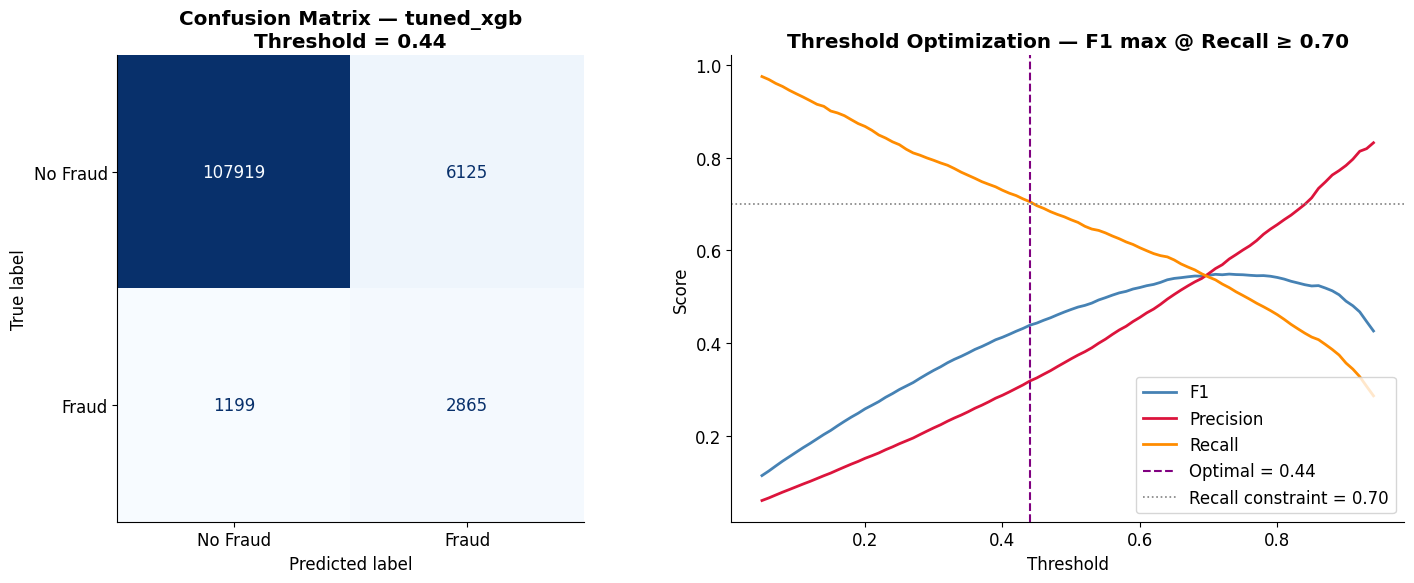

Validation set results @ threshold = 0.44:
  Fraud caught   (TP): 2,865   — 70.5% of all fraud detected
  Fraud missed   (FN): 1,199
  False alarm    (FP): 6,125   — 5.4% of legit transactions flagged
  Correct clear  (TN): 107,919


In [4]:
if model_name == "stacking":
    xgb_p     = joblib.load(MODELS_DIR / "tuned_xgb.pkl").predict_proba(X_val)[:, 1]
    lgb_p     = joblib.load(MODELS_DIR / "tuned_lgb.pkl").predict_proba(X_val)[:, 1]
    cat_p     = joblib.load(MODELS_DIR / "tuned_cat.pkl").predict_proba(X_val)[:, 1]
    meta      = joblib.load(MODELS_DIR / "stacking_meta.pkl")
    best_prob = meta.predict_proba(np.column_stack([xgb_p, lgb_p, cat_p]))[:, 1]
else:
    parts     = model_name.split("_")
    best_prob = joblib.load(
        MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl"
    ).predict_proba(X_val)[:, 1]

y_pred         = (best_prob >= threshold).astype(int)
cm             = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

disp = ConfusionMatrixDisplay(cm, display_labels=["No Fraud", "Fraud"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(
    f"Confusion Matrix — {model_name}\nThreshold = {threshold:.2f}",
    fontweight="bold"
)

thresholds = np.arange(0.05, 0.95, 0.01)
f1s_   = [f1_score(y_val,        (best_prob >= t).astype(int), zero_division=0) for t in thresholds]
precs_ = [precision_score(y_val, (best_prob >= t).astype(int), zero_division=0) for t in thresholds]
recs_  = [recall_score(y_val,    (best_prob >= t).astype(int), zero_division=0) for t in thresholds]

axes[1].plot(thresholds, f1s_,   label="F1",                 color="steelblue",  lw=2)
axes[1].plot(thresholds, precs_, label="Precision",           color="crimson",    lw=2)
axes[1].plot(thresholds, recs_,  label="Recall",              color="darkorange", lw=2)
axes[1].axvline(threshold, color="purple", ls="--", lw=1.5,  label=f"Optimal = {threshold:.2f}")
axes[1].axhline(0.70, color="gray",   ls=":",  lw=1.2,       label="Recall constraint = 0.70")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Threshold Optimization — F1 max @ Recall ≥ 0.70", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "03_confusion_matrix_threshold.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Validation set results @ threshold = {threshold:.2f}:")
print(f"  Fraud caught   (TP): {tp:,}   — {tp/(tp+fn)*100:.1f}% of all fraud detected")
print(f"  Fraud missed   (FN): {fn:,}")
print(f"  False alarm    (FP): {fp:,}   — {fp/(fp+tn)*100:.1f}% of legit transactions flagged")
print(f"  Correct clear  (TN): {tn:,}")

---
## 4. Feature Importance

XGBoost gain-based importance for top 30 features.

**Color coding:**
- 🔴 **Crimson** — Engineered features (`FE_*`): custom signals from EDA and domain knowledge
- 🟠 **Coral** — NaN indicator flags (`_isnan`): absence of data is itself a predictive signal
- 🔵 **Steel blue** — Raw dataset features (V, C, M, id columns from Vesta)

**Notable engineered features in top 30:**
- `FE_R_email_high_risk` — receiver email domain fraud risk flag. EDA found 7 domains with fraud rate > 2× average. This feature became the **#2 most important feature** overall.
- `FE_D9_normalized` — D9 column normalized by `TransactionDT`. Removes time drift; makes the feature client-stable across the dataset timeline.

> **Saved:** `outputs/figures/fraud/model/04_feature_importance.png`

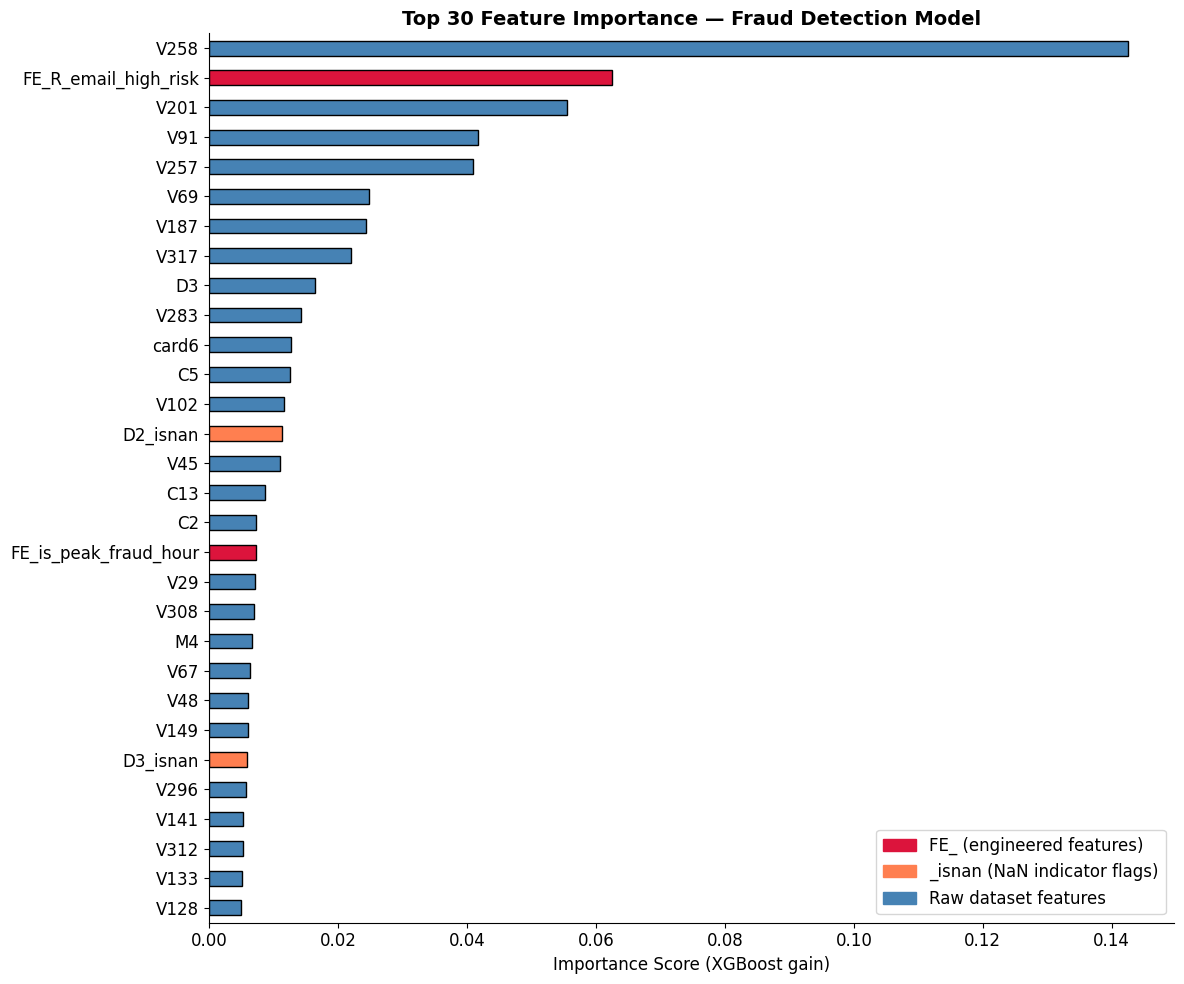

Top 30 breakdown: FE_=2 | _isnan=2 | Raw=26

Top 10 features:
  # 1  V258                                0.1425
  # 2  FE_R_email_high_risk                0.0625 [engineered]
  # 3  V201                                0.0555
  # 4  V91                                 0.0417
  # 5  V257                                0.0409
  # 6  V69                                 0.0248
  # 7  V187                                0.0244
  # 8  V317                                0.0221
  # 9  D3                                  0.0164
  #10  V283                                0.0143


In [5]:
if model_name != "stacking":
    parts    = model_name.split("_")
    fi_model = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    feat_imp = pd.Series(
        fi_model.feature_importances_, index=X_val.columns
    ).sort_values(ascending=False).head(30)
else:
    xgb = joblib.load(MODELS_DIR / "tuned_xgb.pkl")
    lgb = joblib.load(MODELS_DIR / "tuned_lgb.pkl")
    cat = joblib.load(MODELS_DIR / "tuned_cat.pkl")
    feat_imp = (
        pd.Series(xgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(lgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(cat.feature_importances_, index=X_val.columns) / 3
    ).sort_values(ascending=False).head(30)

colors_fi = [
    "crimson"   if c.startswith("FE_") else
    "coral"     if c.endswith("_isnan") else
    "steelblue"
    for c in feat_imp.index
]

fig, ax = plt.subplots(figsize=(12, 10))
feat_imp.plot(kind="barh", ax=ax, color=colors_fi, edgecolor="black")
ax.invert_yaxis()
ax.set_title("Top 30 Feature Importance — Fraud Detection Model",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score (XGBoost gain)")

fe_patch  = mpatches.Patch(color="crimson",   label="FE_ (engineered features)")
nan_patch = mpatches.Patch(color="coral",     label="_isnan (NaN indicator flags)")
raw_patch = mpatches.Patch(color="steelblue", label="Raw dataset features")
ax.legend(handles=[fe_patch, nan_patch, raw_patch], loc="lower right")

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "04_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

fe_in_top30  = sum(1 for c in feat_imp.index if c.startswith("FE_"))
nan_in_top30 = sum(1 for c in feat_imp.index if c.endswith("_isnan"))
raw_in_top30 = len(feat_imp) - fe_in_top30 - nan_in_top30
print(f"Top 30 breakdown: FE_={fe_in_top30} | _isnan={nan_in_top30} | Raw={raw_in_top30}")
print("\nTop 10 features:")
for i, (feat, score) in enumerate(feat_imp.head(10).items(), 1):
    tag = " [engineered]" if feat.startswith("FE_") else ""
    print(f"  #{i:2d}  {feat:<35} {score:.4f}{tag}")

---
## 5. Feature Engineering Impact

Quantifying how much engineered features contribute to the model's predictive power.

**Total features selected:** 204  
- 47 engineered (`FE_*`) including 14 D_normalized
- 9 NaN indicator flags
- 148 raw dataset features

The pie chart shows the feature count distribution. The bar chart shows **total importance weight** captured by each group — a direct measure of how much each group drives predictions.

> **Saved:** `outputs/figures/fraud/model/05_feature_engineering_impact.png`

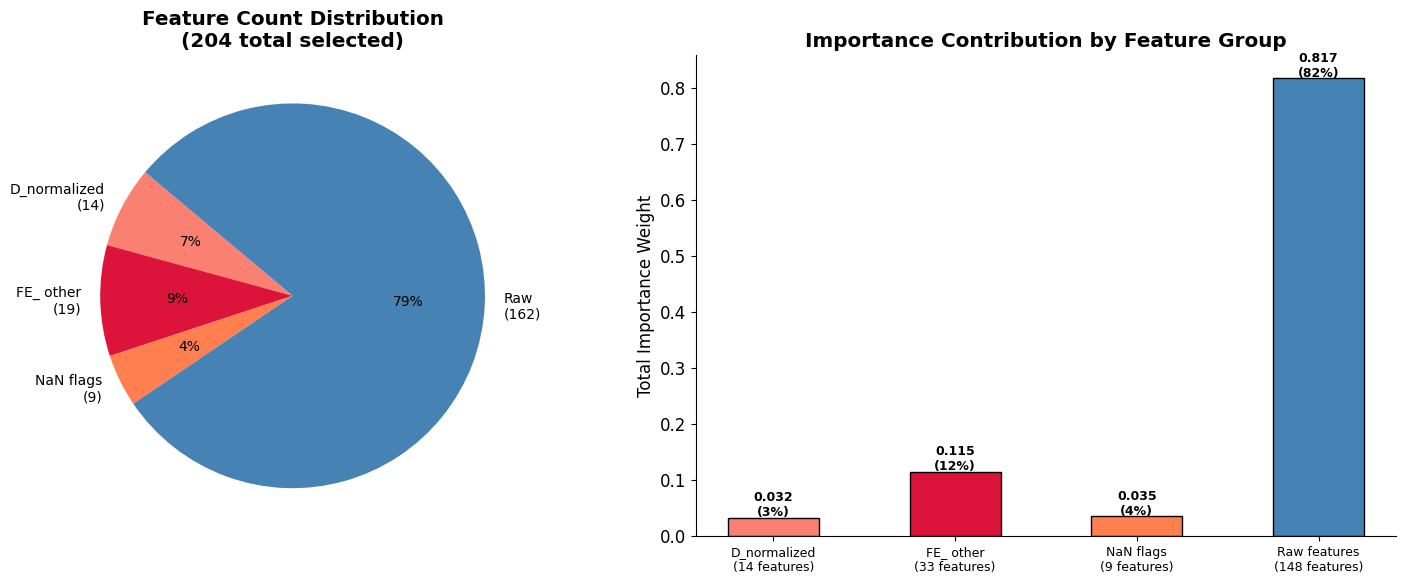

Importance share by feature group:
  Raw features (148 features)    0.8171  (81.7%)
  FE_ other (33 features)        0.1153  (11.5%)
  NaN flags (9 features)         0.0353  (3.5%)
  D_normalized (14 features)     0.0323  (3.2%)


In [6]:
fe_cols  = [c for c in X_val.columns if c.startswith("FE_")]
nan_cols = [c for c in X_val.columns if c.endswith("_isnan")]
raw_cols = [c for c in X_val.columns if not c.startswith("FE_") and not c.endswith("_isnan")]
d_norm   = [c for c in fe_cols if "normalized" in c]
fe_other = [c for c in fe_cols if "normalized" not in c]

if model_name != "stacking":
    parts    = model_name.split("_")
    fi_model = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    imp_all  = pd.Series(fi_model.feature_importances_, index=X_val.columns)
else:
    xgb = joblib.load(MODELS_DIR / "tuned_xgb.pkl")
    lgb = joblib.load(MODELS_DIR / "tuned_lgb.pkl")
    cat = joblib.load(MODELS_DIR / "tuned_cat.pkl")
    imp_all = (
        pd.Series(xgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(lgb.feature_importances_, index=X_val.columns) / 3 +
        pd.Series(cat.feature_importances_, index=X_val.columns) / 3
    )

group_imp = {
    "D_normalized\n(14 features)" : imp_all[d_norm].sum(),
    "FE_ other\n(33 features)"    : imp_all[fe_other].sum(),
    "NaN flags\n(9 features)"     : imp_all[nan_cols].sum(),
    "Raw features\n(148 features)": imp_all[raw_cols].sum(),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie — feature count
sizes  = [len(d_norm), len(fe_other), len(nan_cols), len(raw_cols)]
labels = [f"D_normalized\n({len(d_norm)})", f"FE_ other\n({len(fe_other)})",
          f"NaN flags\n({len(nan_cols)})", f"Raw\n({len(raw_cols)})",]
colors_pie = ["salmon", "crimson", "coral", "steelblue"]
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct="%1.0f%%",
            startangle=140, textprops={"fontsize": 10})
axes[0].set_title(f"Feature Count Distribution\n({len(X_val.columns)} total selected)",
                  fontweight="bold")

# Bar — importance weight
bar_colors = ["salmon", "crimson", "coral", "steelblue"]
bars = axes[1].bar(
    range(len(group_imp)), list(group_imp.values()),
    color=bar_colors, edgecolor="black", width=0.5
)
axes[1].set_xticks(range(len(group_imp)))
axes[1].set_xticklabels(list(group_imp.keys()), fontsize=9)
axes[1].set_ylabel("Total Importance Weight")
axes[1].set_title("Importance Contribution by Feature Group", fontweight="bold")
total_imp = sum(group_imp.values())
for bar, val in zip(bars, group_imp.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f"{val:.3f}\n({val/total_imp*100:.0f}%)",
                 ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_BASE / "model" / "05_feature_engineering_impact.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Importance share by feature group:")
for g, v in sorted(group_imp.items(), key=lambda x: x[1], reverse=True):
    print(f"  {g.replace(chr(10),' '):<30} {v:.4f}  ({v/total_imp*100:.1f}%)")

---
## 6. Overfitting Analysis — Train vs Validation

Gap between train and validation AUC-ROC is a diagnostic for generalization.

| Status | Gap threshold | Interpretation |
|---|---|---|
| ✅ PASS | < 0.02 | Excellent generalization |
| ⚠️ WARN | 0.02 – 0.05 | Mild overfitting, acceptable |
| ❌ OVERFIT | > 0.05 | Model memorizing training data |

**Context:** Some train-val gap is inherent to gradient boosting on large datasets. Regularization was applied in Optuna's search space: `max_depth ≤ 6`, `min_child_weight ≥ 5`, `reg_alpha/lambda` up to 20. The **validation AUC-ROC (0.9258) is the model's true generalization score** and is the only number that matters for deployment.

> **Saved:** `outputs/figures/fraud/model/06_overfitting_analysis.png`

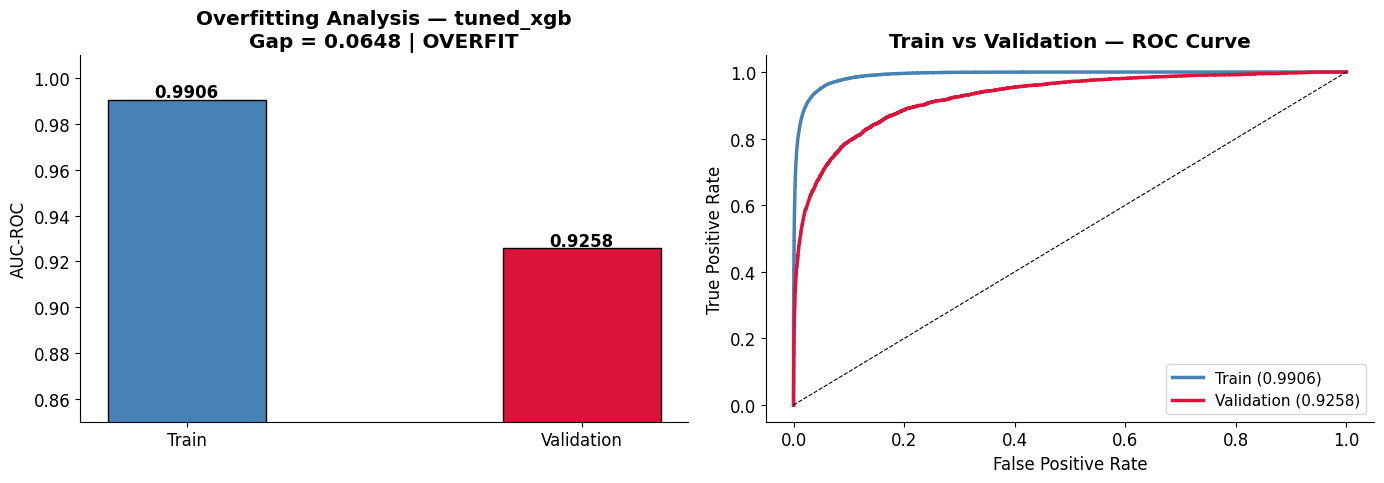

Train AUC      : 0.9906
Validation AUC : 0.9258
Gap            : 0.0648 → OVERFIT


In [9]:
train   = pd.read_parquet(FEATURES_DIR / "train_fraud_features.parquet")
X_train = train.drop(columns=["isFraud"])
y_train = train["isFraud"]

if model_name != "stacking":
    parts      = model_name.split("_")
    chk_model  = joblib.load(MODELS_DIR / f"{parts[0]}_{parts[1]}.pkl")
    train_prob = chk_model.predict_proba(X_train)[:, 1]
    train_auc  = roc_auc_score(y_train, train_prob)
    val_auc    = metadata["auc_roc"]
    gap        = train_auc - val_auc
    status = "PASS" if gap < 0.02 else "WARN" if gap < 0.05 else "OVERFIT"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bars = axes[0].bar(
        ["Train", "Validation"], [train_auc, val_auc],
        color=["steelblue", "crimson"], edgecolor="black", width=0.4
    )
    axes[0].set_ylim(0.85, 1.01)
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_title(
        f"Overfitting Analysis — {model_name}\nGap = {gap:.4f} | {status}",
        fontweight="bold"
    )
    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", fontweight="bold", fontsize=12
        )

    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_prob)
    fpr_v,  tpr_v,  _ = roc_curve(y_val,   best_prob)
    axes[1].plot(fpr_tr, tpr_tr, color="steelblue", lw=2.5, label=f"Train ({train_auc:.4f})")
    axes[1].plot(fpr_v,  tpr_v,  color="crimson",   lw=2.5, label=f"Validation ({val_auc:.4f})")
    axes[1].plot([0,1],[0,1], "k--", lw=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("Train vs Validation — ROC Curve", fontweight="bold")
    axes[1].legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(FIG_BASE / "model" / "06_overfitting_analysis.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Train AUC      : {train_auc:.4f}")
    print(f"Validation AUC : {val_auc:.4f}")
    print(f"Gap            : {gap:.4f} → {status}")
else:
    print("Stacking: overfitting check not applicable (trained on OOF predictions)")

---
## 7. Final Summary

Complete results for the FinRiskGuard fraud detection pipeline.

In [8]:
print("=" * 60)
print("FINRISKGUARD — FRAUD DETECTION FINAL SUMMARY")
print("=" * 60)
print(f"\nBest model       : {model_name}")
print(f"AUC-ROC          : {metadata['auc_roc']:.4f}  (primary metric)")
print(f"AUC-PR           : {metadata['auc_pr']:.4f}  (secondary metric)")
print(f"F1-score         : {metadata['f1']:.4f}")
print(f"Precision        : {metadata['precision']:.4f}")
print(f"Recall           : {metadata['recall']:.4f}")
print(f"Threshold        : {metadata['threshold']:.3f}")
print(f"CV method        : {metadata.get('cv_method', 'N/A')}")
print(f"Calibration      : {metadata.get('calibration', 'N/A')}")
print(f"Features used    : {len(X_val.columns)}")
print(f"  FE_ engineered : {len(fe_cols)}")
print(f"  D_normalized   : {len(d_norm)}")
print(f"  NaN flags      : {len(nan_cols)}")
print(f"  Raw features   : {len(raw_cols)}")
print(f"\nSaved figures:")
for f in sorted(FIG_BASE.rglob("*.png")):
    rel = f.relative_to(FIG_BASE.parent.parent)
    print(f"  {rel}")

FINRISKGUARD — FRAUD DETECTION FINAL SUMMARY

Best model       : tuned_xgb
AUC-ROC          : 0.9258  (primary metric)
AUC-PR           : 0.5637  (secondary metric)
F1-score         : 0.4389
Precision        : 0.3187
Recall           : 0.7050
Threshold        : 0.440
CV method        : TimeSeriesSplit(n_splits=5)
Calibration      : isotonic (cv=prefit per fold)
Features used    : 204
  FE_ engineered : 33
  D_normalized   : 14
  NaN flags      : 9
  Raw features   : 162

Saved figures:
  figures\fraud\comparison\01_model_leaderboard.png
  figures\fraud\eda\01_target\target_analysis.png
  figures\fraud\eda\02_missing\missing_overview.png
  figures\fraud\eda\03_amount\amount_analysis.png
  figures\fraud\eda\04_temporal\temporal_analysis.png
  figures\fraud\eda\05_card\card_features.png
  figures\fraud\eda\06_email\email_domain_analysis.png
  figures\fraud\eda\07_browser_device\browser_device_analysis.png
  figures\fraud\eda\08_c_d_v_m\cdmv_analysis.png
  figures\fraud\eda\09_identity\v_i